# Start

In [1]:
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt
import random

In [2]:
img = Image.open('image-3.png').convert('L')
img = img.resize((28, 28))

In [3]:
# Нормализуем пиксели в диапазон от 0 до 1
pixels = np.array(img)/255

In [4]:
# # Преобразуем в одномерный вектор
inputs = pixels.flatten()
print("Количество входов нейрона:", len(inputs))
print("Входные данные нейрона:", inputs.tolist())

Количество входов нейрона: 784
Входные данные нейрона: [0.7529411764705882, 0.6431372549019608, 0.3686274509803922, 0.3137254901960784, 0.25882352941176473, 0.2235294117647059, 0.2, 0.1607843137254902, 0.13725490196078433, 0.13725490196078433, 0.3686274509803922, 0.807843137254902, 0.8666666666666667, 0.8117647058823529, 0.3843137254901961, 0.19607843137254902, 0.19215686274509805, 0.19215686274509805, 0.20392156862745098, 0.20392156862745098, 0.2196078431372549, 0.34901960784313724, 0.611764705882353, 0.7647058823529411, 0.788235294117647, 0.792156862745098, 0.8, 0.7725490196078432, 0.7647058823529411, 0.6235294117647059, 0.3764705882352941, 0.3137254901960784, 0.25098039215686274, 0.23529411764705882, 0.21176470588235294, 0.16470588235294117, 0.14901960784313725, 0.17254901960784313, 0.4745098039215686, 0.7176470588235294, 0.788235294117647, 0.8117647058823529, 0.5490196078431373, 0.2, 0.19215686274509805, 0.19215686274509805, 0.21176470588235294, 0.2235294117647059, 0.21960784313725

In [5]:
np.random.seed(42)

In [6]:
weights = np.random.randn(len(inputs))
bias = np.random.randn()

# print(bias, weights)

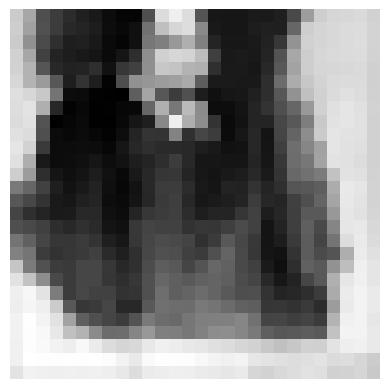

In [7]:
plt.imshow(img, cmap='gray')
plt.axis('off')
plt.show() 

In [8]:
print("Количество входов:", len(inputs))
print("Форма weights:", weights.shape)
print("Пример первых 5 весов:", weights[:5])
print("Bias:", bias) 

Количество входов: 784
Форма weights: (784,)
Пример первых 5 весов: [ 0.49671415 -0.1382643   0.64768854  1.52302986 -0.23415337]
Bias: 0.5597904479310398


In [9]:
# Напишите код функции ReLU - верните «обрезанное» значение — минимум 0, максимум x.
# Ваш код здесь

def relu(x):
    return np.maximum(0, x)

# Допишите код функции нейрона.
def neuron(inputs, weights, bias):
    # Вычислите total = сумма + bias
    total = np.dot(inputs, weights) + bias
    # Примените ReLU
    output = relu(total)
    return output

output = neuron(inputs, weights, bias)
print("Выход нейрона:", output) 

Выход нейрона: 0.0


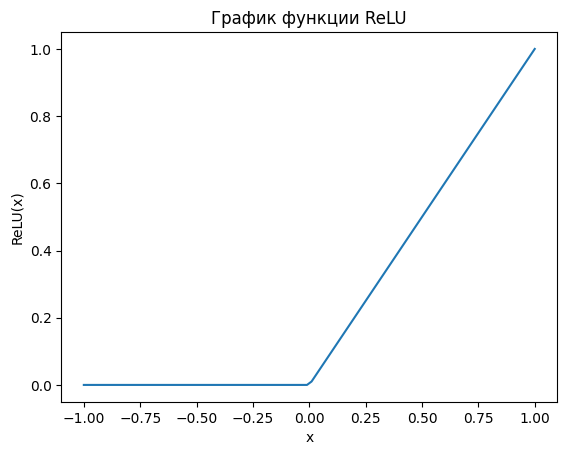

In [10]:
x = np.linspace(-1, 1, 100)
y = relu(x)  # применяем вашу функцию

plt.plot(x, y)
plt.title("График функции ReLU")
plt.xlabel("x")
plt.ylabel("ReLU(x)")
plt.show()

In [11]:
pixels.shape

(28, 28)

In [12]:
def pixelwise_neuron(pixels, weights, bias):
    flat = pixels.flatten()
    activated = relu(flat * weights + bias)  # применяем нейрон к каждому пикселю
    return activated.reshape(pixels.shape) 

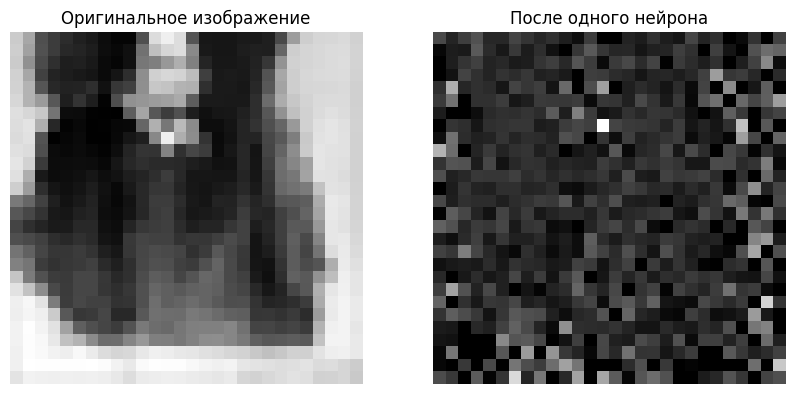

In [13]:
np.random.seed(42) 
img = Image.open("image-3.png").convert('L')
img = img.resize((28, 28))
pixels = np.array(img) / 255.0
weights = np.random.randn(28 * 28)
bias = np.random.randn()

def relu(x): 
    return np.maximum(0, x)

# Допишите функцию pixelwise_neuron: которая берёт pixels, превращает в плоский вектор, затем поэлементно умножает на weights и прибавляет bias, применяет вашу функцию relu ко всем элементам, восстанавливает форму (28×28) и возвращает результат.

# Примените только что написанную функцию к изображению
processed =  pixelwise_neuron(pixels=pixels, weights=weights, bias=bias) # Ваш код здесь 

fig, axs = plt.subplots(1, 2, figsize=(10, 5))
axs[0].imshow(pixels, cmap='gray')
axs[0].set_title('Оригинальное изображение')
axs[0].axis('off')

axs[1].imshow(processed, cmap='gray')
axs[1].set_title('После одного нейрона')
axs[1].axis('off')

plt.show()

In [14]:
pixels.shape

(28, 28)

Что нужно сделать
Визуализируйте работу нейрона без смещения. Допишите код в отмеченных местах. Используйте функцию нейрона, которую вы реализовали в прошлом уроке.

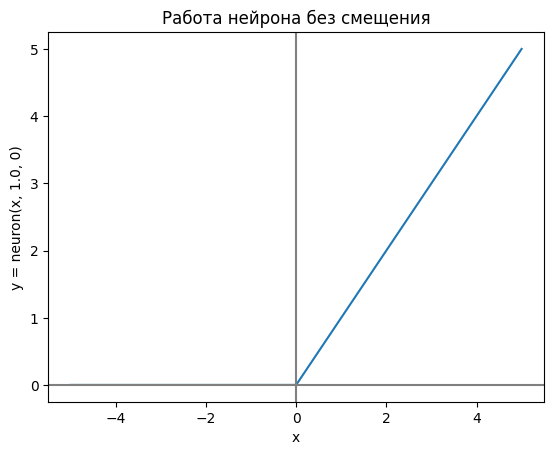

In [15]:
import numpy as np
import matplotlib.pyplot as plt

def relu(x):
    return np.maximum(0, x)

def neuron(x, weight, bias):
    return relu(weight * x + bias)

# Генерируем входные значения
x_vals = np.linspace(-5, 5, 200)
# Вычисляем выход нейрона без смещения (weight=1.0, bias=0)
y_vals = neuron(x_vals, weight=1.0, bias=0)

# Строим график
plt.plot(x_vals, y_vals)
plt.title('Работа нейрона без смещения')
plt.axhline(0, color='gray')
plt.axvline(0, color='gray')
plt.xlabel('x')
plt.ylabel('y = neuron(x, 1.0, 0)')
plt.show()

Теперь визуализируем работу того же нейрона со смещением 
b
=
−
3.
b=−3.

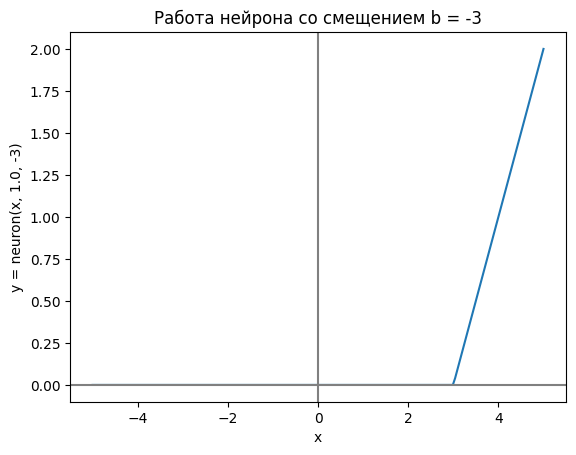

In [16]:
# Генерируем входные значения
x_vals = np.linspace(-5, 5, 200)
# Вычисляем выход нейрона со смещением (weight=1.0, bias)
y_vals = neuron(x_vals, weight=1.0, bias=-3)

# Строим график
plt.plot(x_vals, y_vals)
plt.title('Работа нейрона со смещением b = -3')
plt.axhline(0, color='gray')
plt.axvline(0, color='gray')
plt.xlabel('x')
plt.ylabel('y = neuron(x, 1.0, -3)')
plt.show()

Посмотрим, как разные значения смещения 
b
b меняют форму графика
y
=
ReLU
(
w
x
+
b
)
.
y=ReLU(wx+b). Зафиксируем 
w
=
1.0
w=1.0 и будем менять значения смещения. 

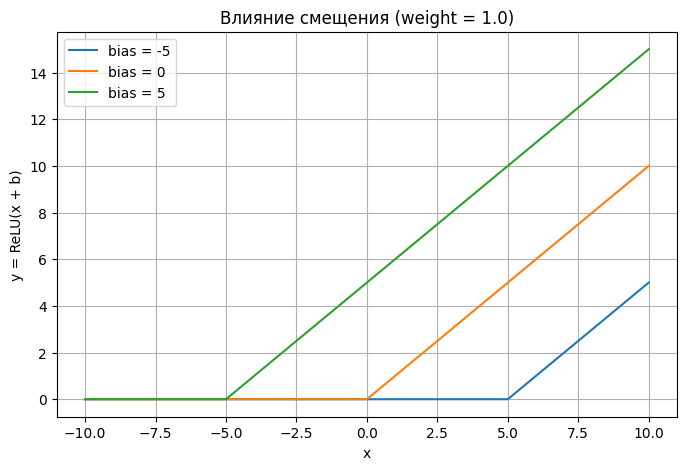

In [17]:
# диапазон входов
x = np.linspace(-10, 10, 400)
weight = 1.0
biases = [-5, 0, 5]

plt.figure(figsize=(8, 5))
for b in biases:
    y = neuron(x, weight, b)
    plt.plot(x, y, label=f"bias = {b}")

plt.title("Влияние смещения (weight = 1.0)")
plt.xlabel("x")
plt.ylabel("y = ReLU(x + b)")
plt.legend()
plt.grid(True)
plt.show()

Что нужно сделать
Запустите код и проанализируйте, как разные значения веса 
w
w меняют наклон графика при 
b
=
0.
b=0.

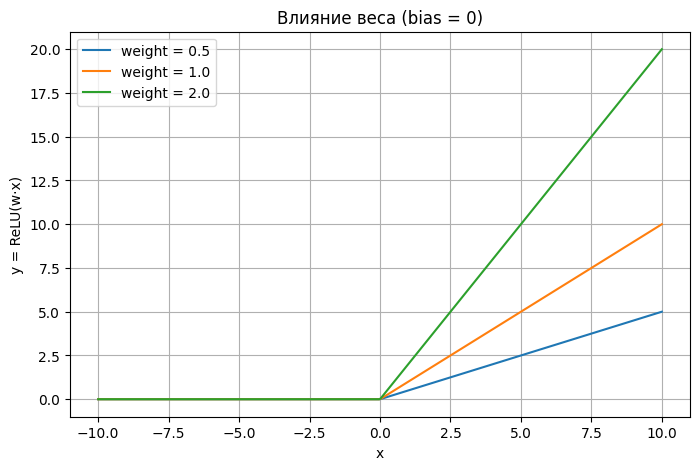

In [18]:
# диапазон входов
x = np.linspace(-10, 10, 400)
bias = 0
weights = [0.5, 1.0, 2.0]

plt.figure(figsize=(8, 5))
for w in weights:
    y = neuron(x, w, bias)
    plt.plot(x, y, label=f"weight = {w}")

plt.title("Влияние веса (bias = 0)")
plt.xlabel("x")
plt.ylabel("y = ReLU(w·x)")
plt.legend()
plt.grid(True)
plt.show()

Видно, что вес влияет на наклон функции активации. Чем больше 
w
,
w, тем меньше угол наклона графика к оси 
x
,
x, то есть тем важнее параметр для принятия решения. 
Зафиксируем: 
Вес определяет, как сильно входной сигнал влияет на активацию нейрона: чем больше вес, тем круче подъём функции активации.
Смещение управляет тем, при каком значении входа нейрон «включается»: оно сдвигает функцию активации по оси 
x
.
x.

# Sigmoid

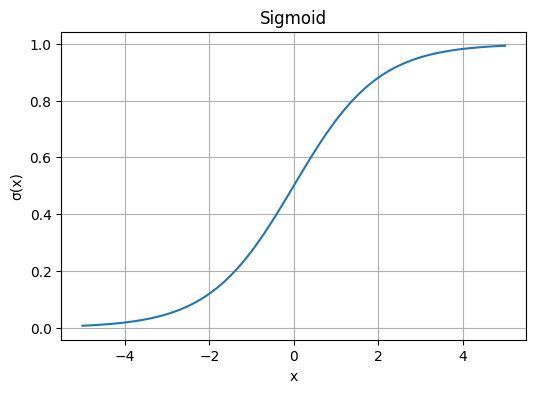

In [19]:
import math

def sigmoid(x: float) -> float:
    return 1 / (1 + math.exp(-x))

x_vals = [i * 0.1 for i in range(-50, 51)] # Генерируем значения от -5 до 5 с шагом 0.1
y_vals = [sigmoid(x) for x in x_vals] # Применяем функцию sigmoid к каждому значению

plt.figure(figsize=(6,4))
plt.plot(x_vals, y_vals)
plt.title("Sigmoid")
plt.xlabel("x")
plt.ylabel("σ(x)")
plt.grid(True)
plt.show()

In [20]:
len(x_vals)

101

# Tan h

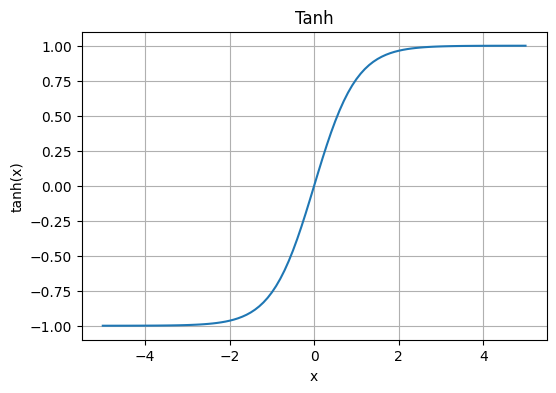

In [21]:
def tanh(x: float) -> float:
    return math.tanh(x)

x_vals = [i * 0.1 for i in range(-50, 51)]
y_vals = [tanh(x) for x in x_vals]
plt.figure(figsize=(6,4))
plt.plot(x_vals, y_vals)
plt.title("Tanh")
plt.xlabel("x")
plt.ylabel("tanh(x)")
plt.grid(True)
plt.show()

# ReLU

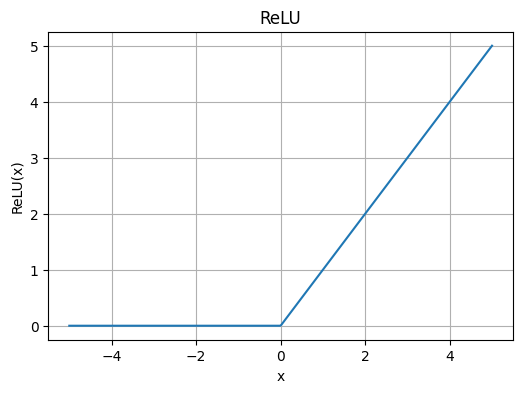

In [22]:
def relu(x):
    return np.maximum(0, x)

x_vals = np.linspace(-5, 5, 400)
y_vals = relu(x_vals)
plt.figure(figsize=(6,4))
plt.plot(x_vals, y_vals)
plt.title("ReLU")
plt.xlabel("x")
plt.ylabel("ReLU(x)")
plt.grid(True)
plt.show()

# Leaky ReLU

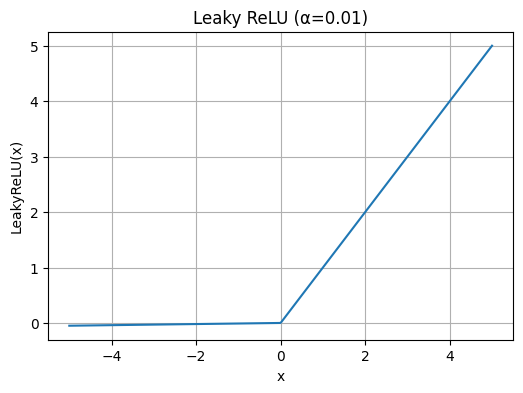

In [23]:
def leaky_relu(x, alpha=0.01):
    return np.where(x >= 0, x, alpha * x)

x_vals = np.linspace(-5, 5, 400)
y_vals = leaky_relu(x_vals)
plt.figure(figsize=(6,4))
plt.plot(x_vals, y_vals)
plt.title("Leaky ReLU (α=0.01)")
plt.xlabel("x")
plt.ylabel("LeakyReLU(x)")
plt.grid(True)
plt.show()

# Softmax

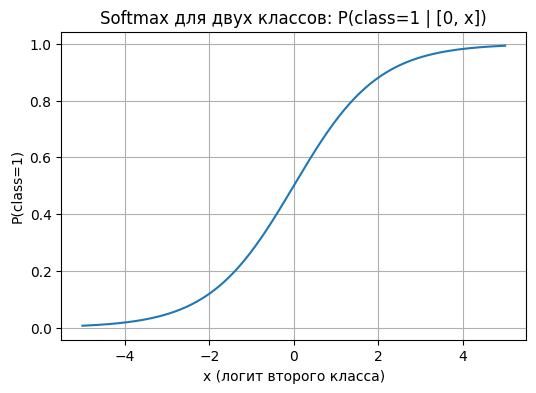

In [24]:
def softmax(z):
    # 1) для стабильности вычитаем максимум
    e_z = np.exp(z - np.max(z))
    # 2) нормируем экспоненты, чтобы сумма = 1
    return e_z / e_z.sum()

# диапазон значений второго логита
x_vals = np.linspace(-5, 5, 400)
# для каждого x считаем только P(class=1) в Softmax([0, x])
p1 = [softmax([0, x])[1] for x in x_vals]

plt.figure(figsize=(6,4))
plt.plot(x_vals, p1)
plt.title("Softmax для двух классов: P(class=1 | [0, x])")
plt.xlabel("x (логит второго класса)")
plt.ylabel("P(class=1)")
plt.grid(True)
plt.show() 

# GeLU

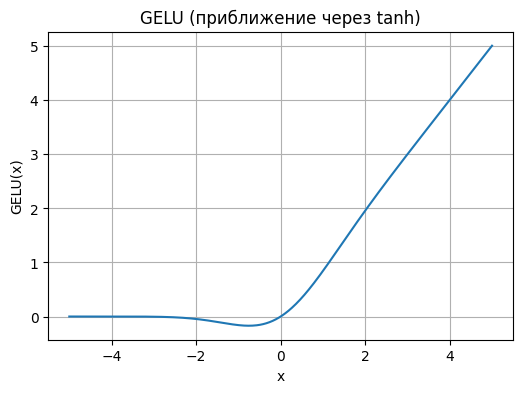

In [25]:
def gelu(x: np.ndarray) -> np.ndarray:
    # Приближение через tanh
    return 0.5 * x * (1 + np.tanh(np.sqrt(2/np.pi)*(x + 0.044715 * x**3)))

# Диапазон для визуализации
x_vals = np.linspace(-5, 5, 400)
y_vals = gelu(x_vals)

plt.figure(figsize=(6,4))
plt.plot(x_vals, y_vals)
plt.title("GELU (приближение через tanh)")
plt.xlabel("x")
plt.ylabel("GELU(x)")
plt.grid(True)
plt.show()

Формат задания
Выполните задание локально на своём устройстве: скопируйте код ниже, реализуйте шаги и проанализируйте результаты. 
Проверить задание вы сможете самостоятельно. В конце выполнения нажмите кнопку «Готово» и увидите авторское решение — с ним вы можете сверить свой вариант. 
Что нужно сделать
Реализуйте популярные функции активации, примените их к синтетическим данным и визуализируете результат. Допишите код в отмеченных местах. 

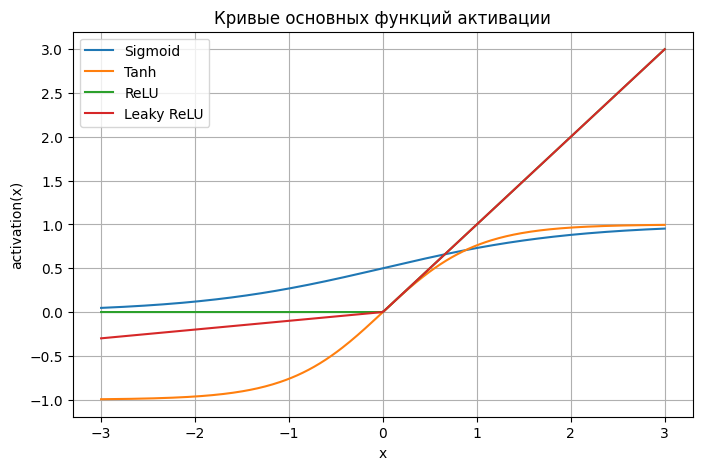

In [26]:
# 1) Входные данные
x = np.linspace(-3, 3, 300)

# 2) Реализация функций активации

def sigmoid(x):
    return 1/(1+ np.exp(-x))
    

def tanh_act(x):
    return (np.exp(x) - np.exp(-x))/(np.exp(x) + np.exp(-x))

def relu(x):
    return np.maximum(0, x)

def leaky_relu(x, alpha=0.1):
    return np.where(x >= 0 , x, alpha*x)
    pass

# 3) Вычисление значений (раскомментируйте после реализации функций)
y_sig = sigmoid(x)
y_tanh = tanh_act(x)
y_relu = relu(x)
y_leaky = leaky_relu(x)

# 4) Визуализация (оставьте без изменений)
plt.figure(figsize=(8, 5))
plt.plot(x, y_sig, label='Sigmoid')
plt.plot(x, y_tanh, label='Tanh')
plt.plot(x, y_relu, label='ReLU')
plt.plot(x, y_leaky, label='Leaky ReLU')

plt.title('Кривые основных функций активации')
plt.xlabel('x')
plt.ylabel('activation(x)')
plt.legend()
plt.grid(True)
plt.show()

# MLP

In [27]:
"""
Создадим цикл инициализации параметров в многослойный перцептрон SampleMLP с параметрами layer_sizes, который принимает list, 
содержащий числа нейронов в каждом слое, включая входной и выходной. 
И activation: строка, указывающая функцию активации (здесь только 'sigmoid'). выглядит так:
"""
class MLP:
    def __init__(self, layer_sizes, activation='sigmoid'):
        self.layer_sizes = layer_sizes
        self.activation = activation
        self.W = []
        self.b = []

        for i in range(len(layer_sizes)-1):
            in_dim = layer_sizes[i]
            out_dim = layer_sizes[i+1]

            weight_matrix = np.random.randn(in_dim, out_dim) * 0.1
            bias_vector = np.zeros((1, out_dim))

            self.W.append(weight_matrix)
            self.b.append(bias_vector)

    def _sigmoid(self, Z):
        return 1/(1+np.exp(-Z))
    
    def forward(self, X):
        """
        Реализуйте метод forward в классе MLP. Метод получает X формы (batch_size, in_dim) и должен пройти по всем слоям: 
        для каждого слоя вычислить Z = A.dot(W) + b, для скрытых слоёв использовать sigmoid(Z), а для последнего слоя вернуть линейный Z (без sigmoid). 
        Веса в self.W имеют форму (in_dim, out_dim), смещения self.b = (1, out_dim).
        """
        A = X
        for i, (W, b) in enumerate(zip(self.W, self.b)):
            Z = A.dot(W) + b
            if i < len(self.W) - 1:
                A = self._sigmoid(Z)
            else:
                A = Z
                
        return A
    
    def forward_with_activations(self, X):
        activations = [X]
        A = X
        for i, (W, b) in enumerate(zip(self.W, self.b)):
            Z = A.dot(W) + b
            if i < len(self.W) - 1:
                A = self._sigmoid(Z)
            else:
                A = Z
            activations.append(A)
        return activations


In [28]:
np.random.seed(42)
# Инициализируем модель с 4 слоями: 10 входов, 32 нейрона, 16 нейронов и 5 выходов
model = MLP([10, 32, 16, 5], activation='sigmoid')
# Создаём случайный входной массив размером 100 примеров по 10 признаков
X_rand = np.random.randn(100, 10)
# Запускаем прямой проход
out = model.forward(X_rand)
print("Output shape:", out.shape)
# ожидаем (100, 5) 

Output shape: (100, 5)


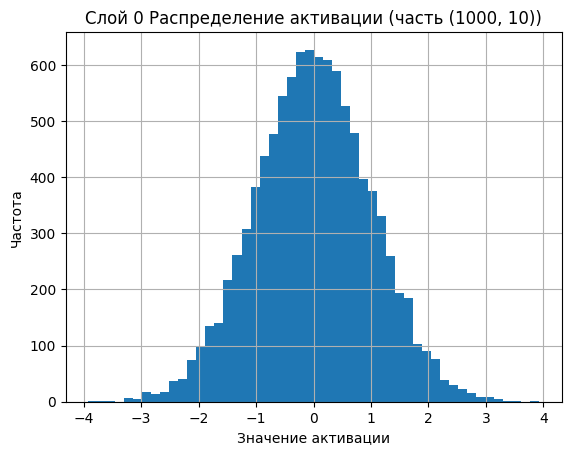

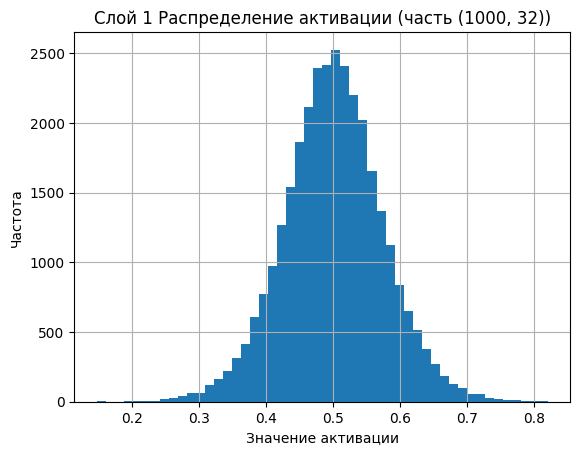

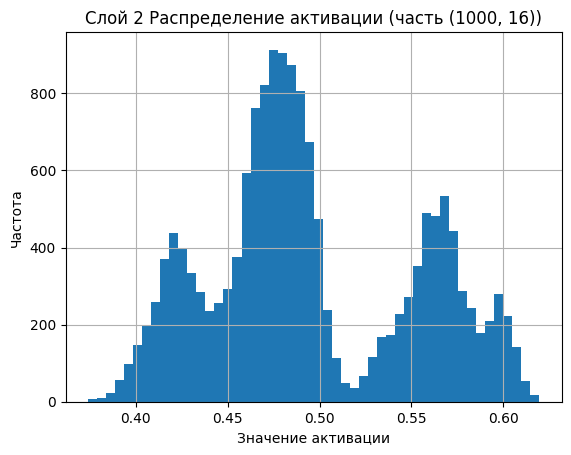

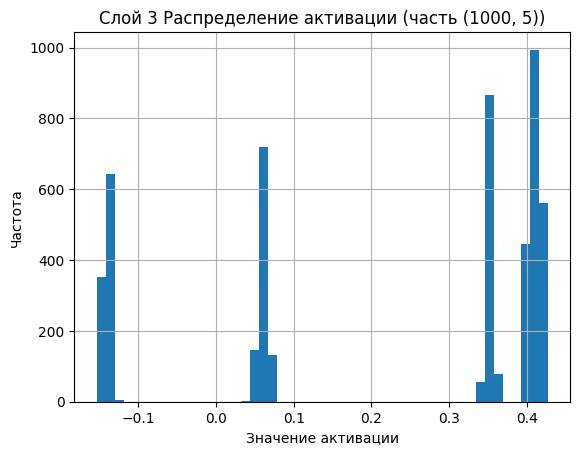

In [29]:
# Инициализируем модель с 4 слоями: 10 входов, 32 нейрон, 16 нейронов и 5 выходов
np.random.seed(42)
model = MLP([10, 32, 16, 5], activation='sigmoid')
X_rand = np.random.randn(1000, 10)

# Соберем активации
acts = model.forward_with_activations(X_rand)

# Отобразим активации каждого слоя
for idx, A in enumerate(acts):
    plt.figure()
    plt.hist(A.flatten(), bins=50)
    plt.title(f'Слой {idx} Распределение активации (часть {A.shape})')
    plt.xlabel('Значение активации')
    plt.ylabel('Частота')
    plt.grid(True)
    plt.show() 

# Forward Passing

In [30]:
"""
Создадим цикл инициализации параметров в многослойный перцептрон SampleMLP с параметрами layer_sizes, который принимает list, 
содержащий числа нейронов в каждом слое, включая входной и выходной. 
И activation: строка, указывающая функцию активации (здесь только 'sigmoid'). выглядит так:
"""
class MLP:
    def __init__(self, layer_sizes, activation='sigmoid'):
        self.layer_sizes = layer_sizes
        self.activation = activation
        self.W = []
        self.b = []
        self.Z_list, self.A_list = [], []

        for i in range(len(layer_sizes)-1):
            in_dim = layer_sizes[i]
            out_dim = layer_sizes[i+1]

            weight_matrix = np.random.randn(in_dim, out_dim) * 0.1
            bias_vector = np.zeros((1, out_dim))

            self.W.append(weight_matrix)
            self.b.append(bias_vector)

    def _sigmoid(self, Z):
        return 1/(1+np.exp(-Z))
    
    def _relu(self, Z):
        return np.maximum(0, Z)
    
    def forward(self, X):
        """
        Реализуйте метод forward в классе MLP. Метод получает X формы (batch_size, in_dim) и должен пройти по всем слоям: 
        для каждого слоя вычислить Z = A.dot(W) + b, для скрытых слоёв использовать sigmoid(Z), а для последнего слоя вернуть линейный Z (без sigmoid). 
        Веса в self.W имеют форму (in_dim, out_dim), смещения self.b = (1, out_dim).
        """

        # очищаем списки перед новым вызовом
        A = X
        self.Z_list, self.A_list = [], []

        # сохраните инициализацию входного слоя в A_list
        self.A_list.append(A)

        for i, (W, b) in enumerate(zip(self.W, self.b)):
            # сохраняем линейную часть Z в Z_list
            Z = A.dot(W) + b
            self.Z_list.append(Z)

            if i < len(self.W) - 1:
                match self.activation:
                    case 'sigmoid':
                        A = self._sigmoid(Z)
                    case 'relu':
                        A = self._relu(Z)
                    case _:
                        raise ValueError(f"Unknown activation {self.activation}")
            else:
                A = Z

            # сохраняется активация выходного слоя в A_list
            self.A_list.append(A)
                
        return A
    
    def forward_with_activations(self, X):
        activations = [X]
        A = X
        for i, (W, b) in enumerate(zip(self.W, self.b)):
            Z = A.dot(W) + b
            if i < len(self.W) - 1:
                A = self._sigmoid(Z)
            else:
                A = Z
            activations.append(A)
        return activations


In [31]:
"""
1. Добавьте в MLP метод _tanh и ветку для активации 'tanh'.
2. Запустите три модели с архитектурой [3,2,1] для активаций 'relu', 'sigmoid', 'tanh'.
3. Выведите на экран последний y_pred и длины списков Z_list и A_list.
"""

class MLP:
    def __init__(self, layer_sizes, activation='sigmoid'):
        self.layer_sizes = layer_sizes
        self.activation = activation
        self.W = []
        self.b = []
        self.Z_list, self.A_list = [], []

        for i in range(len(layer_sizes)-1):
            in_dim = layer_sizes[i]
            out_dim = layer_sizes[i+1]

            weight_matrix = np.random.randn(in_dim, out_dim) * 0.1
            bias_vector = np.zeros((1, out_dim))

            self.W.append(weight_matrix)
            self.b.append(bias_vector)

    def _sigmoid(self, Z):
        return 1/(1+np.exp(-Z))
    
    def _relu(self, Z):
        return np.maximum(0, Z)
    
    def _tanh(self, Z):
        return np.tanh(Z)
    
    def forward(self, X):
        """
        Реализуйте метод forward в классе MLP. Метод получает X формы (batch_size, in_dim) и должен пройти по всем слоям: 
        для каждого слоя вычислить Z = A.dot(W) + b, для скрытых слоёв использовать sigmoid(Z), а для последнего слоя вернуть линейный Z (без sigmoid). 
        Веса в self.W имеют форму (in_dim, out_dim), смещения self.b = (1, out_dim).
        """

        # очищаем списки перед новым вызовом
        A = X
        self.Z_list, self.A_list = [], []

        # сохраните инициализацию входного слоя в A_list
        self.A_list.append(A)

        for i, (W, b) in enumerate(zip(self.W, self.b)):
            # сохраняем линейную часть Z в Z_list
            Z = A.dot(W) + b
            self.Z_list.append(Z)

            if i < len(self.W) - 1:
                match self.activation:
                    case 'sigmoid':
                        A = self._sigmoid(Z)
                    case 'relu':
                        A = self._relu(Z)
                    case 'tanh':
                        A = self._tanh(Z)
                    case _:
                        raise ValueError(f"Unknown activation {self.activation}")
            else:
                A = Z

            # сохраняется активация выходного слоя в A_list
            self.A_list.append(A)
                
        return A
    
    def forward_with_activations(self, X):
        activations = [X]
        A = X
        for i, (W, b) in enumerate(zip(self.W, self.b)):
            Z = A.dot(W) + b
            if i < len(self.W) - 1:
                A = self._sigmoid(Z)
            else:
                A = Z
            activations.append(A)
        return activations


In [32]:
x = np.array([[1.0, 2.0, -1.0]])
for act in ['relu', 'sigmoid', 'tanh']:
    np.random.seed(0)
    model = MLP([3,2,1], activation=act)
    y_pred = model.forward(x)
    print(f"{act}: y_pred={y_pred.ravel()[0]:.4f}, "
          f"len(Z_list)={len(model.Z_list)}, len(A_list)={len(model.A_list)}")

    # Отобразим значения Z и A
    for i, (Z, A) in enumerate(zip(model.Z_list, model.A_list)):
        print(f"Layer {i}: Z={Z.ravel()}, A={A.ravel()}")
    print() 

relu: y_pred=0.0087, len(Z_list)=2, len(A_list)=3
Layer 0: Z=[0.18539703 0.58592215], A=[ 1.  2. -1.]
Layer 1: Z=[0.008746], A=[0.18539703 0.58592215]

sigmoid: y_pred=0.0422, len(Z_list)=2, len(A_list)=3
Layer 0: Z=[0.18539703 0.58592215], A=[ 1.  2. -1.]
Layer 1: Z=[0.04217181], A=[0.54621695 0.64242895]

tanh: y_pred=0.0094, len(Z_list)=2, len(A_list)=3
Layer 0: Z=[0.18539703 0.58592215], A=[ 1.  2. -1.]
Layer 1: Z=[0.00943941], A=[0.18330168 0.52695644]



# Backpropagation

In [33]:
"""
Что нужно сделать
Рассмотрим простую функцию: 
y=w⋅x
"""
import numpy as np

w = 1.0
x = 2.0
y_true = 10.0

def loss(w):
    # Предсказание
    y_pred = w * x
    
    return np.mean((y_true - y_pred)**2)
    


print("Исходная потеря:", loss(w))
for h in [0.01, -0.01]:
    l_new = loss(w + h)
    print(f"w изменился на {h:+.2f}, новая потеря: {l_new}")

Исходная потеря: 64.0
w изменился на +0.01, новая потеря: 63.680400000000006
w изменился на -0.01, новая потеря: 64.32039999999999


In [34]:
"""
1. Добавьте в MLP метод _tanh и ветку для активации 'tanh'.
2. Запустите три модели с архитектурой [3,2,1] для активаций 'relu', 'sigmoid', 'tanh'.
3. Выведите на экран последний y_pred и длины списков Z_list и A_list.
"""

class MLP:
    def __init__(self, layer_sizes, activation='sigmoid'):
        self.layer_sizes = layer_sizes
        self.activation = activation
        self.W = []
        self.b = []
        self.Z_list, self.A_list = [], []

        for i in range(len(layer_sizes)-1):
            in_dim = layer_sizes[i]
            out_dim = layer_sizes[i+1]

            weight_matrix = np.random.randn(in_dim, out_dim) * 0.1
            bias_vector = np.zeros((1, out_dim))

            self.W.append(weight_matrix)
            self.b.append(bias_vector)

    def _activate(self, Z):
        if self.activation == 'sigmoid':
            return 1/(1+np.exp(-Z))
        elif self.activation == 'relu':
            return np.maximum(0, Z)
        elif self.activation == 'tanh':
            return np.tanh(Z)
        else:
            raise ValueError(self.activation)

    def _dactivate(self, Z):
        if self.activation == 'sigmoid':
            s = 1/(1+np.exp(-Z))
            return s*(1-s)
        
        elif self.activation == 'relu':
            return (Z > 0).astype(float)
        
        elif self.activation == 'tanh':
            return 1 - np.tanh(Z)**2
        
    def mse(self, y_pred, y_true):
        return np.mean((y_pred - y_true)**2)

    def _sigmoid(self, Z):
        return 1/(1+np.exp(-Z))
    
    def _relu(self, Z):
        return np.maximum(0, Z)
    
    def _tanh(self, Z):
        return np.tanh(Z)
    
    def forward(self, X):
        """
        Реализуйте метод forward в классе MLP. Метод получает X формы (batch_size, in_dim) и должен пройти по всем слоям: 
        для каждого слоя вычислить Z = A.dot(W) + b, для скрытых слоёв использовать sigmoid(Z), а для последнего слоя вернуть линейный Z (без sigmoid). 
        Веса в self.W имеют форму (in_dim, out_dim), смещения self.b = (1, out_dim).
        """

        # очищаем списки перед новым вызовом
        A = X
        self.Z_list, self.A_list = [], []

        # сохраните инициализацию входного слоя в A_list
        self.A_list.append(A)

        for i, (W, b) in enumerate(zip(self.W, self.b)):
            # сохраняем линейную часть Z в Z_list
            Z = A.dot(W) + b
            self.Z_list.append(Z)

            if i < len(self.W) - 1:
                match self.activation:
                    case 'sigmoid':
                        A = self._sigmoid(Z)
                    case 'relu':
                        A = self._relu(Z)
                    case 'tanh':
                        A = self._tanh(Z)
                    case _:
                        raise ValueError(f"Unknown activation {self.activation}")
            else:
                A = Z

            # сохраняется активация выходного слоя в A_list
            self.A_list.append(A)
                
        return A
    
    def forward_with_activations(self, X):
        activations = [X]
        A = X
        for i, (W, b) in enumerate(zip(self.W, self.b)):
            Z = A.dot(W) + b
            if i < len(self.W) - 1:
                A = self._sigmoid(Z)
            else:
                A = Z
            activations.append(A)
        return activations
    
    def backward(self, y_true):
        """Метод должен пройти от выходного слоя к входному и вычислить градиенты весов и смещений для каждого слоя по формулам backpropagation. 
        Для выходного слоя используется линейная активация и MSE: дельта на выходе равна 2*(aL - y_true)/m. 
        Сохраните градиенты в списках self.dW_list и self.db_list в том же порядке, что и self.W и self.b (т. е. dW_list[i] соответствует W[i])."""

        m = y_true.shape[0]

        # δ на выходном слое (линейный + MSE)
        aL = self.A_list[-1]
        # δ^L = 2*(A^L - Y)/m
        delta = 2*(aL - y_true)/m

        # Градиенты для выходного слоя
        a_prev = self.A_list[-2]
        # dW^L = A^{L-1}ᵀ · δ^L
        dW = a_prev.T.dot(delta)
        db = np.sum(delta, axis=0, keepdims=True)
        self.dW_list, self.db_list = [dW], [db]

        # 3) Обратный проход по скрытым слоям (sigmoid)
        for l in range(len(self.layer_sizes) - 2, 0, -1):
            z = self.Z_list[l-1]       
            a_prev = self.A_list[l-1]
            W_next = self.W[l]

            # δ^l = (δ^{l+1} · W^{l+1}ᵀ) * σ'(z^l)
            delta = delta.dot(W_next.T) * self._dactivate(z)
            # dW^l = A^{l-1}ᵀ · δ^l
            dW = a_prev.T.dot(delta)
            db = np.sum(delta, axis=0, keepdims=True)

            self.dW_list.insert(0, dW)  # вставляем вперёд
            self.db_list.insert(0, db) 

    def update_params(self, lr):
        # Обновляем веса и смещения
        for i in range(len(self.W)):
            # Обновляем веса W и смещения b.
             self.W[i] -= lr * self.dW_list[i]

             self.b[i] -= lr * self.db_list[i]



In [35]:
w = 0.0
x = 1.5
y = 2.0
lr = 0.1

def loss(w):
    return (w*x - y)**2

for epoch in range(1, 6):
    # прямой проход и градиент
    y_pred = w * x
    grad = 2*(y_pred - y) * x   # dC/dw для MSE
    # обновление веса
    w = w - lr * grad
    print(f"Epoch {epoch}: w = {w:.4f}, loss = {loss(w):.4f}")

Epoch 1: w = 0.6000, loss = 1.2100
Epoch 2: w = 0.9300, loss = 0.3660
Epoch 3: w = 1.1115, loss = 0.1107
Epoch 4: w = 1.2113, loss = 0.0335
Epoch 5: w = 1.2662, loss = 0.0101


In [36]:
"""

"""

np.random.seed(0)
X = np.linspace(0, 1, 100)
Y = 2 * X + 1 + np.random.randn(100) * 0.1

w = 0.0
b = 0.0
lr = 0.1

for epoch in range(1, 101):
    y_pred = w * X + b
    error = y_pred - Y

    # 1. Градиенты по w и b
    grad_w = np.mean(2*error*x)
    grad_b = np.mean(2*error)

    # 2. Обновление параметров
    w = w - lr * grad_w
    b = b - lr * grad_w

    if epoch % 20 == 0:
        mse = np.mean(error ** 2)
        print(f"Epoch {epoch}: w={w:.4f}, b={b:.4f}, loss={mse:.4f}")

print(f"\nИтог: w={w:.4f} (ожидаем ≈2), b={b:.4f} (ожидаем ≈1)")

Epoch 20: w=1.3373, b=1.3373, loss=0.0441
Epoch 40: w=1.3373, b=1.3373, loss=0.0441
Epoch 60: w=1.3373, b=1.3373, loss=0.0441
Epoch 80: w=1.3373, b=1.3373, loss=0.0441
Epoch 100: w=1.3373, b=1.3373, loss=0.0441

Итог: w=1.3373 (ожидаем ≈2), b=1.3373 (ожидаем ≈1)


# Аппроксимация Sin функции

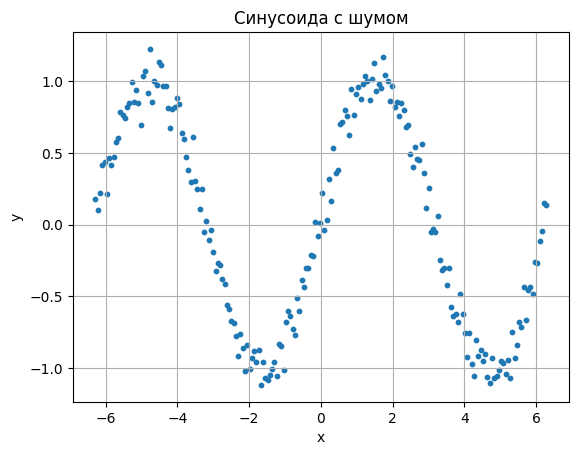

In [37]:
import matplotlib.pyplot as plt

np.random.seed(0)
X = np.linspace(-2*np.pi, 2*np.pi, 200)[:, None]  # (200,1)
y = np.sin(X) + 0.1*np.random.randn(*X.shape)     # шумные данные

plt.scatter(X, y, s=10)
plt.title("Синусоида с шумом")
plt.xlabel("x")
plt.ylabel("y")
plt.grid(True)
plt.show()

In [38]:
model = MLP([1, 30, 1], activation='tanh')

# \# Небольшая проверка (опционально)
xx = np.random.randn(5, 1)
out = model.forward(xx)
print("out.shape =", out.shape)  # ожидаем (5,1) 

out.shape = (5, 1)


In [55]:
def run_learning():
    lr = 0.01
    epochs = 300
    batch_size = 30
    loss_history = []

    for epoch in range(1, epochs+1):
        perm = np.random.permutation(len(X))
        X_sh, y_sh = X[perm], y[perm]
        for start in range(0, len(X), batch_size):
            xb = X_sh[start:start+batch_size]
            yb = y_sh[start:start+batch_size]

            # Прямой проход
            preds = model.forward(xb)

            # Обратный проход
            model.backward(yb)

            # Обновление параметров
            model.update_params(lr)

        full_pred = model.forward(X)

        # Считаем потери на данных и добавляем в историю
        loss_history.append(model.mse(full_pred, y))
        
        # Выводим потери каждые 50 эпох
        if epoch % 50 == 0:
            print(f"Epoch {epoch:3d}, loss={loss_history[-1]:.4f}")

    # Визуализация
    plt.figure(figsize=(12,4))
    plt.subplot(1,2,1)
    plt.plot(loss_history)
    plt.title("MSE по эпохам")
    plt.xlabel("Эпоха")
    plt.grid(True)
    plt.subplot(1,2,2)
    xx = np.linspace(-2*np.pi, 2*np.pi, 200)[:, None]
    plt.plot(xx, np.sin(xx), label="sin(x)")
    plt.plot(xx, model.forward(xx), label="MLP")
    plt.legend()
    plt.grid(True)
    plt.show()

Epoch  50, loss=0.0496
Epoch 100, loss=0.0485
Epoch 150, loss=0.0480
Epoch 200, loss=0.0477
Epoch 250, loss=0.0472
Epoch 300, loss=0.0484


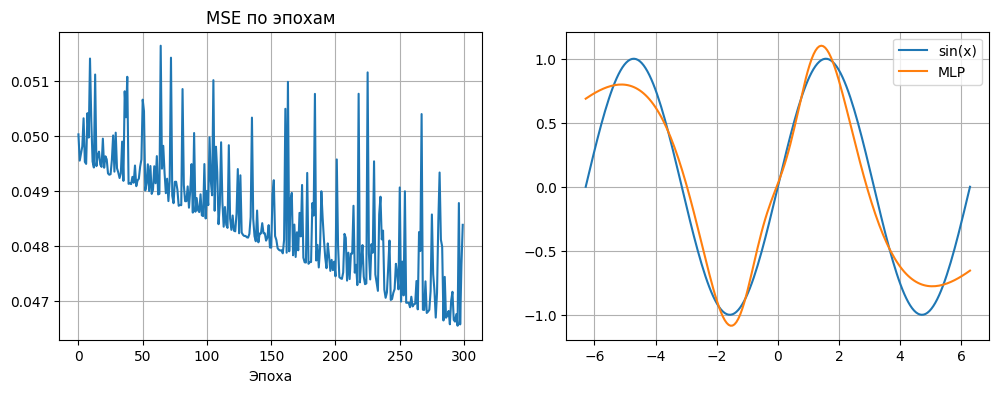

In [56]:
run_learning()

# Модуль 2

### Обучение нейронных сетей

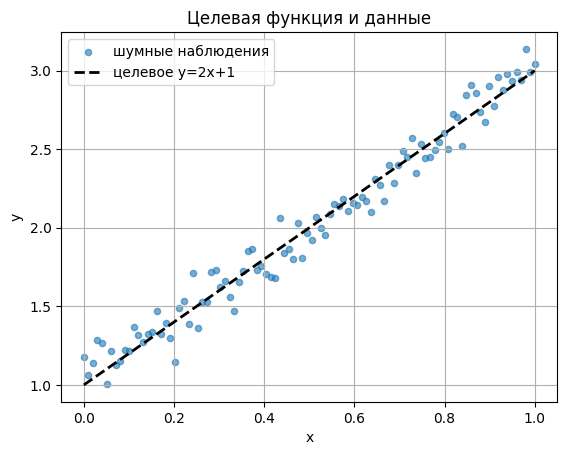

In [57]:
import numpy as np
import matplotlib.pyplot as plt

# Данные
np.random.seed(0)
X = np.linspace(0, 1, 100)[:, None]          # (100,1)
Y = 2 * X + 1 + np.random.randn(100,1)*0.1  # шумные точки

# Визуализация
plt.scatter(X, Y, s=20, alpha=0.6, label='шумные наблюдения')
# Чистая прямая y=2x+1
x_line = np.linspace(0,1,100)
plt.plot(x_line, 2*x_line+1, 'k--', linewidth=2, label='целевое y=2x+1')
plt.title("Целевая функция и данные")
plt.xlabel("x")
plt.ylabel("y")
plt.legend()
plt.grid(True)
plt.show()

Epoch  2: loss=2.6566, ||grad||=3.5829
Epoch  4: loss=0.9091, ||grad||=2.0014
Epoch  6: loss=0.3627, ||grad||=1.1238
Epoch  8: loss=0.1892, ||grad||=0.6408
Epoch 10: loss=0.1317, ||grad||=0.3810


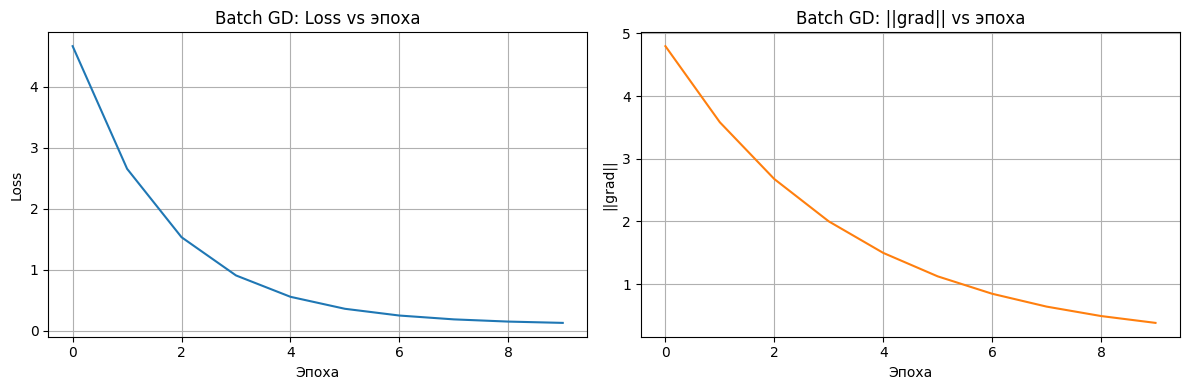

In [60]:
"""
Обучим MLP([1, 1]) (линейную модель) методом полного градиентного спуска (Batch GD). 
На каждом шаге градиент вычисляется по всей выборке. Ваша задача — после обратного прохода собрать все градиенты (по весам dW и смещениям db) в единый вектор и вычислить его евклидову норму. 
Это позволит отслеживать, насколько «сильно» модель хочет изменить параметры на каждом шаге.
"""

# Класс MLP был реализован в прошлых уроках

model = MLP([1, 1], activation='tanh')
lr, epochs = 0.1, 10

loss_history = []
grad_norms = []

for epoch in range(1, epochs + 1):
    preds = model.forward(X)
    loss = model.mse(preds, Y)
    loss_history.append(loss)

    model.backward(Y)

    # Соберите ВСЕ градиенты (dW и db) в один плоский вектор
    grads = np.concatenate(
        [g.ravel() for g in model.db_list] +
        [g.ravel() for g in model.dW_list]
        )

    # 2. Вычислите евклидову норму вектора grads
    norm = np.linalg.norm(grads)
    grad_norms.append(norm)

    model.update_params(lr)

    if epoch % 2 == 0:
        print(f"Epoch {epoch:>2d}: loss={loss:.4f}, ||grad||={grad_norms[-1]:.4f}")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(loss_history, color='tab:blue')
ax1.set(title="Batch GD: Loss vs эпоха", xlabel="Эпоха", ylabel="Loss")
ax1.grid(True)

ax2.plot(grad_norms, color='tab:orange')
ax2.set(title="Batch GD: ||grad|| vs эпоха", xlabel="Эпоха", ylabel="||grad||")
ax2.grid(True)

plt.tight_layout()
plt.show()

### Mini-Batch GD

Epoch  1: loss=0.3592
Epoch  2: loss=0.0967
Epoch  3: loss=0.0728
Epoch  4: loss=0.0633
Epoch  5: loss=0.0566
Epoch  6: loss=0.0507
Epoch  7: loss=0.0456
Epoch  8: loss=0.0411
Epoch  9: loss=0.0374
Epoch 10: loss=0.0338


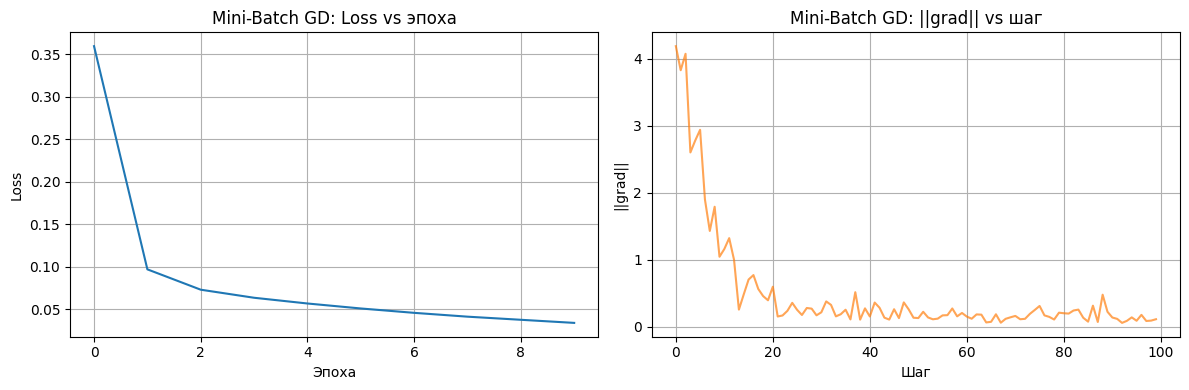

In [62]:
# MLP и данные (X, Y) уже загружены

model = MLP([1, 1], activation='tanh')
lr = 0.05
epochs = 10
batch_size = 10

loss_history = []
grad_norms = []

for epoch in range(1, epochs + 1):
    perm = np.random.permutation(len(X))

    for start in range(0, len(X), batch_size):
        idxs = perm[start : start + batch_size]
        xb, yb = X[idxs], Y[idxs]

        # Прямой и обратный проход по батчу
        model.forward(xb)
        model.backward(yb)

        # Соберите норму градиента (как в заданиях 2–3)
        grads = np.concatenate(
            [g.ravel() for g in model.db_list] +
            [g.ravel() for g in model.dW_list]
        )
        grad_norms.append(np.linalg.norm(grads))

        # Обновите параметры
        model.update_params(lr=lr)

    # Loss после эпохи
    loss = model.mse(model.forward(X), Y)
    loss_history.append(loss)
    print(f"Epoch {epoch:>2d}: loss={loss:.4f}")

# --- Визуализация (ничего менять не нужно) ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(loss_history, color='tab:blue')
ax1.set(title="Mini-Batch GD: Loss vs эпоха", xlabel="Эпоха", ylabel="Loss")
ax1.grid(True)

ax2.plot(grad_norms, color='tab:orange', alpha=0.7)
ax2.set(title="Mini-Batch GD: ||grad|| vs шаг", xlabel="Шаг", ylabel="||grad||")
ax2.grid(True)

plt.tight_layout()
plt.show()

# Функции потерь

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(0)
X = np.linspace(0, 1, 100)[:, None]          # (100,1)
Y = 2 * X + 1 + np.random.randn(100,1)*0.1  # шумные точки


class MLP:
    def __init__(self, layer_sizes, activation='tanh'):
        self.layer_sizes = layer_sizes
        self.activation = activation
        self.W, self.b = [], []
        self.Z_list, self.A_list = [], []
        self.dW_list, self.db_list = [], []
        for i in range(len(layer_sizes)-1):
            in_dim, out_dim = layer_sizes[i], layer_sizes[i+1]
            self.W.append(np.random.randn(in_dim, out_dim) * 0.1)
            self.b.append(np.zeros((1, out_dim)))

    def _activate(self, Z):
        if self.activation == 'sigmoid':
            return 1/(1+np.exp(-Z))
        elif self.activation == 'relu':
            return np.maximum(0, Z)
        elif self.activation == 'tanh':
            return np.tanh(Z)
        else:
            raise ValueError(self.activation)

    def _dactivate(self, Z):
        if self.activation == 'sigmoid':
            s = 1/(1+np.exp(-Z))
            return s*(1-s)
        elif self.activation == 'relu':
            return (Z > 0).astype(float)
        elif self.activation == 'tanh':
            return 1 - np.tanh(Z)**2

    def forward(self, X):
        self.Z_list, self.A_list = [], []
        A = X
        self.A_list.append(A)

        for i in range(len(self.W)):
            Z = A.dot(self.W[i]) + self.b[i]
            self.Z_list.append(Z)
            A = self._activate(Z) if i < len(self.W)-1 else Z
            self.A_list.append(A)
        return A

    def mse(self, y_pred, y_true):
        return np.mean((y_pred - y_true)**2)

    def backward(self, y_true):
        m = y_true.shape[0]
        # выходной слой
        aL, zL = self.A_list[-1], self.Z_list[-1]
        delta = (2*(aL - y_true)/m)
        # градиенты выхода
        a_prev = self.A_list[-2]
        dW = a_prev.T.dot(delta)
        db = np.sum(delta, axis=0, keepdims=True)
        self.dW_list, self.db_list = [dW], [db]
        # скрытые
        for l in range(len(self.layer_sizes)-2, 0, -1):
            z = self.Z_list[l-1]
            a_prev = self.A_list[l-1]
            W_next = self.W[l]
            delta = delta.dot(W_next.T) * self._dactivate(z)
            dW = a_prev.T.dot(delta)
            db = np.sum(delta, axis=0, keepdims=True)
            self.dW_list.insert(0, dW)
            self.db_list.insert(0, db)

    def update_params(self, lr):
        # Градиентный спуск обновляет каждый параметр в сторону, противоположную градиенту.
        # Обновляем веса и смещения
        for i in range(len(self.W)):
            self.W[i] -= lr * self.dW_list[i]
            self.b[i] -= lr * self.db_list[i]


def mse(y, y_pred):
    return np.mean((y - y_pred)**2)

def mae(y, y_pred):
    return np.mean(np.abs(y-y_pred))

def huber(y_pred, y_true, delta=5):
    diff = y_pred - y_true
    small = np.abs(diff) <= delta
    sq = 0.5 * diff**2
    lin = delta*(np.abs(diff) - 0.5*delta)
    return np.mean(np.where(small, sq, lin))

np.random.seed(0)
X = np.linspace(0, 1, 100)[:, None]
# Создаём линейную зависимость с шумом в виде np.random.randn(100,1)*0.1
Y = # Ваш код здесь


model = MLP([1,1], activation='tanh')
lr, epochs = 0.1, 50


# Истории для трёх loss
loss_mse, loss_mae, loss_huber = [], [], []

for epoch in range(1, epochs+1):
    preds = model.forward(X)

    # Считаем все три loss
    loss_mse.append(model.mse(preds, Y))
    loss_mae.append(np.mean(np.abs(preds - Y)))
    loss_huber.append(huber(preds, Y, delta=1.0))  # увеличили delta

    # Обучение
    model.backward(Y)
    model.update_params(lr)

# Визуализация
plt.figure(figsize=(8,5))
plt.plot(range(1, epochs+1), loss_mse, label='MSE')
plt.plot(range(1, epochs+1), loss_mae, label='MAE')
plt.plot(range(1, epochs+1), loss_huber, label='Huber (δ=1.0)')
plt.title("Снижение функций потерь по эпохам")
plt.xlabel("Эпоха")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()